<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Automated_Mathematical_Derivation_Engine_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Automated Mathematical Derivation Engine

## Motivation

Automated mathematical derivation requires more than a sequence of algebraic transformations. Each step carries assumptions about the expressions involved, and competing paths introduce different computational costs or representations of the same mathematical object. An inspectable engine must preserve those assumptions alongside the reasoning used to accept each transformation.

Within Google Colab, a small, extensible core connects symbolic manipulation to a directed graph of candidate derivations. Configurable search controls guide exploration toward an exact target or a mathematical objective, and separate verification records describe the support available for each step.

## Notation

A symbolic expression identifies a mathematical candidate, yet its derivation history also affects search priority. Representing both the expression and its associated state prevents path-dependent quantities from being mistaken for intrinsic properties of the expression.

| Symbol or identifier        | Definition                                                                                                 |
| --------------------------- | ---------------------------------------------------------------------------------------------------------- |
| $E_0$                       | Starting expression.                                                                                       |
| $E$                         | Expression at the current search state.                                                                    |
| $E'$                        | Candidate expression produced by a transformation.                                                         |
| $E_\star$                   | Target expression for an exact structural objective.                                                       |
| $s$                         | Search state containing an expression, assumptions, and derivation metadata.                               |
| $\Gamma$                    | Assumptions and domain restrictions associated with the state.                                             |
| $r$                         | Transformation rule selected from the registry.                                                            |
| $d(s)$                      | Number of transformations along the path associated with state $s$.                                        |
| $R$                         | Symbolic residual between the current expression and its target.                                           |
| $\equiv_{\mathrm{struct}}$  | Structural equality of symbolic representations.                                                           |
| $\models$                   | Logical entailment under stated assumptions.                                                               |
| $\land$                     | Logical conjunction.                                                                                       |
| $C(s)$                      | Weighted score used to prioritize a search state.                                                          |
| $C_{\mathrm{depth}}$        | Penalty associated with derivation depth.                                                                  |
| $C_{\mathrm{operations}}$   | Operation count of the current expression.                                                                 |
| $C_{\mathrm{target}}$       | Penalty associated with structural target matching and the simplified residual.                            |
| $C_{\mathrm{canonical}}$    | Objective-specific penalty for departure from a preferred representation.                                  |
| $C_{\mathrm{rule}}$         | Cost obtained from transformation metadata in the registry.                                                |
| $C_{\mathrm{verification}}$ | Penalty assigned to the recorded verification outcome.                                                     |
| $w_d,w_o,w_t,w_c,w_r,w_v$   | Nonnegative weights for the six score components.                                                          |
| $f(s)$                      | Priority used by an A* search formulation.                                                                 |
| $g(s)$                      | Accumulated path cost from the initial state to state $s$.                                                 |
| $h(s)$                      | Estimated remaining cost from state $s$ to a goal.                                                         |
| `sympy.count_ops`           | SymPy function that counts symbolic operations.                                                            |
| `sympy.simplify`            | SymPy function that attempts heuristic simplification.                                                     |
| SMT                         | Satisfiability modulo theories, used for checking logical formulas within supported mathematical theories. |
| DAG                         | Directed acyclic graph.                                                                                    |
| CPU / GPU                   | Central processing unit / graphics processing unit.                                                        |
| CUDA                        | NVIDIA platform used by CuPy for compatible GPU computations.                                              |

Zero denotes an absent penalty, an exact residual, or the initial path length as appropriate. The unit offset in the target penalty is a scoring convention.

## Fundamental Theory and Verification Semantics

A transformation proposes a new representation of an expression under a declared mathematical domain. Accepting that proposal requires a check whose interpretation matches the assumptions and the capabilities of the selected backend.

For a transformation rule $r$, the candidate expression is

$$
E'=r(E).
$$

The required equivalence is

$$
\Gamma \models E=E'.
$$

Here, $\Gamma$ includes restrictions needed for both expressions to be defined. In SymPy, structural equality compares representations; mathematical equivalence may require additional symbolic processing. [1](https://docs.sympy.org/latest/explanation/gotchas.html)

To preserve the interpretation of each result, the engine separates four verification categories.

| Category                    | Acceptance basis                                                                                                | Scope and limitation                                                                                |
| --------------------------- | --------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| Formal proof certificate    | A proof object checked by a proof assistant’s trusted checker.                                                  | Certificate generation lies outside the present engine’s scope.                                     |
| Exact symbolic verification | SymPy reduces the difference between candidate expressions to exact zero under the represented conditions.      | Domain restrictions and transformation assumptions require preservation throughout the calculation. |
| SMT verification            | Z3 reports that the encoded counterexample formula is unsatisfiable.                                            | The conclusion applies to the supported theory and the faithfully encoded assumptions.              |
| Numerical consistency       | mpmath or CuPy evaluates admissible sample points without finding a discrepancy under the configured criterion. | Agreement supports a sampled consistency result, with no universal proof status.                    |

For expressions represented faithfully in a supported theory, Z3 examines the counterexample formula

$$
\Gamma \land (E\ne E').
$$

An unsatisfiable result excludes counterexamples within that encoding. Meanwhile, a satisfiable result supplies a model requiring inspection, and an unknown result or timeout leaves the question unresolved. Z3 supports reasoning across several theories, with coverage determined by the encoded problem. [2](https://www.microsoft.com/en-us/research/publication/z3-an-efficient-smt-solver/)

## Implementation and Control Knobs

A derivation engine must balance the cost of exploration against the mathematical form requested by the objective. Separating computational responsibilities keeps the expression logic independent of graph rendering and numerical diagnostics.

| Component                 | Assigned responsibility                                                           | Boundary                                                                               |
| ------------------------- | --------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| SymPy                     | Performs symbolic transformations and supported exact equivalence checks.         | Exactness requires suitable input representations and preserved assumptions.           |
| NetworkX                  | Maintains the directed graph, traversal logic, path selection, and metadata.      | Graph connectivity alone supplies no mathematical justification for an edge.           |
| Graphviz                  | Renders hierarchical views with labeled expressions and transformations.          | Layout describes the recorded graph without certifying its mathematical content.       |
| Z3                        | Searches for algebraic counterexamples within supported encodings.                | Unsupported statements and unresolved solver outcomes require separate handling.       |
| mpmath                    | Supplies a separate evaluation route for scalar checks at configurable precision. | Higher precision reduces some numerical errors without converting sampling into proof. |
| CuPy                      | Evaluates large numerical batches on an available CUDA GPU.                       | Acceleration applies to compatible numerical computations.                             |
| Optional SageMath backend | Provides a future extension point for advanced algebra and algebraic topology.    | Integration requires an implemented interface and checked conversion semantics.        |

For hierarchical rendering, Graphviz’s `dot` layout arranges directed graphs using ranks and crossing-reduction procedures. Its layout capability also applies to graphs containing cycles. [3](https://graphviz.org/docs/layouts/dot/)

### Scoring Model

Search priorities combine expression properties with information attached to a derivation path. Using a state-dependent score preserves that distinction, especially for depth and the verification outcome of an incoming transformation.

The configured ranking function is

$$
C(s)=
w_d C_{\mathrm{depth}}
+w_o C_{\mathrm{operations}}
+w_t C_{\mathrm{target}}
+w_c C_{\mathrm{canonical}}
+w_r C_{\mathrm{rule}}
+w_v C_{\mathrm{verification}}.
$$

Each component is evaluated for state $s$, and smaller scores receive higher priority. The six displayed terms account for the complete score.

| Component      | Definition or required convention                                                                | Ranking effect                                               |
| -------------- | ------------------------------------------------------------------------------------------------ | ------------------------------------------------------------ |
| Depth          | Number of transformations along the selected path.                                               | Favors shorter derivations.                                  |
| Operations     | `sympy.count_ops(E)`.                                                                            | Favors fewer counted symbolic operations.                    |
| Target         | Zero for structural equality; otherwise one plus the operation count of the simplified residual. | Rewards an exact target representation.                      |
| Canonical form | Metric declared by the mathematical objective.                                                   | Favors the representation selected by that objective.        |
| Rule           | Cost read from registry metadata, with its local or cumulative interpretation documented.        | Discourages transformations assigned greater cost.           |
| Verification   | Penalty assigned to the recorded checking outcome.                                               | Expresses a configured preference among verification routes. |

To measure path length and expression complexity independently,

$$
C_{\mathrm{depth}}(s)=d(s),
$$

$$
C_{\mathrm{operations}}(s)
=
\operatorname{count\_ops}(E).
$$

SymPy’s operation count describes symbolic structure; it supplies a complexity proxy without directly predicting execution time on a particular processor. [4](https://docs.sympy.org/latest/modules/core.html#sympy.core.function.count_ops)

For an objective with target $E_\star$, define the residual as

$$
R=\operatorname{simplify}(E-E_\star).
$$

The specified target penalty is

$$
C_{\mathrm{target}}(s)=
\begin{cases}
0,
& E\equiv_{\mathrm{struct}}E_\star,\\
1+\operatorname{count\_ops}(R),
& \text{otherwise}.
\end{cases}
$$

This definition reserves zero for a structural match. An algebraically equivalent expression with a different structure receives a penalty of one if its residual simplifies to zero. For objectives without an exact target, disabling the target term avoids introducing an arbitrary reference expression.

Within the verification penalty, exact symbolic verification receives zero, SMT verification receives a small positive value, and numerical-only consistency receives a larger value. These values encode search preferences without establishing a universal ordering of mathematical reliability. A failed transformation may retain a large diagnostic penalty, although failure must also exclude it from accepted derivations; a finite penalty alone provides insufficient protection.

### Search Strategies

Different search orders answer different optimization questions. Comparing their behavior requires a fixed rule registry and acceptance policy, preventing changes in admissible transformations from obscuring the effect of search priority.

| Strategy      | Selection principle                                      | Conditions and limits                                                                                                            |
| ------------- | -------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Breadth first | Explores states by increasing path length.               | Finds a goal with the fewest edges in the explored unweighted graph under complete expansion and appropriate duplicate handling. |
| Best first    | Expands the state with the preferred configured score.   | Provides heuristic guidance without a general guarantee of minimum derivation cost.                                              |
| A* style      | Combines accumulated cost with estimated remaining cost. | Optimality requires additional conditions on costs, the heuristic, and handling of repeated states.                              |

For a standard A* formulation,

$$
f(s)=g(s)+h(s).
$$

Here, $g(s)$ records accumulated cost and $h(s)$ estimates the remaining cost. An admissible heuristic avoids overestimating the true remaining cost; graph-search implementations also require suitable treatment of improved paths. An arbitrary weighted expression score supplies no automatic admissibility guarantee. [5](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.astar.astar_path.html)

## Domain Restrictions and Search Edge Cases

Algebraic rewriting may alter apparent singularities or depend on a chosen branch of a complex function. Retaining the original domain restrictions prevents a simplified expression from silently broadening the accepted mathematical statement.

For symbolic checks, an unresolved residual differs from a demonstrated counterexample. Numerical diagnostics also require separate handling of undefined evaluations and overflow, preventing invalid sample points from being counted as successful agreement.

Within the derivation graph, reversible rules may create cycles. Describing a rendered graph as a DAG requires an acyclic construction, such as a derivation tree with distinct occurrences or an extracted acyclic subgraph.

Repeated expressions introduce another source of ambiguity. Merging them requires compatible assumptions and preservation of any path information used by future decisions, including accumulated costs and verification history.

## Practical Application and Observation

A completed search produces both a candidate result and a record of how the engine reached it. Inspecting that record connects computational performance to the transformations attempted and the checks applied.

| Observable            | Interpretation                                                                                                 |
| --------------------- | -------------------------------------------------------------------------------------------------------------- |
| Goal status           | Whether the declared structural target or mathematical objective was reached.                                  |
| Accepted path         | Ordered transformations supporting the returned expression.                                                    |
| Verification record   | Checking method, assumptions, and outcome associated with each step.                                           |
| Expanded states       | Search effort spent generating candidate successors.                                                           |
| Score contributions   | Influence of each configured term on ranking.                                                                  |
| Final operation count | Structural complexity under the selected counting convention.                                                  |
| Elapsed time          | Combined computational cost of search and checking, with rendering reported separately if measured separately. |
| Numerical coverage    | Sample count, admissible domain, precision, and acceptance criterion used for consistency checks.              |

In a hierarchical rendering, node labels identify expressions and edge labels identify transformations. Accompanying verification metadata permits inspection of the accepted route without relying on visual placement as an indication of correctness.

## Comparison of Approaches

Exact symbolic checks, SMT reasoning, and numerical evaluation examine different aspects of a proposed transformation. Combining them broadens diagnostic coverage, provided each recorded outcome retains its original interpretation.

| Approach                      | Primary contribution                                          | Essential qualification                                                |
| ----------------------------- | ------------------------------------------------------------- | ---------------------------------------------------------------------- |
| Symbolic derivation           | Manipulates expressions using algebraic structure.            | Preserves domain restrictions and rule conditions.                     |
| SMT reasoning                 | Excludes counterexamples within a supported logical encoding. | Requires faithful translation into the selected theory.                |
| Scalar numerical evaluation   | Examines selected inputs at configurable precision.           | Reports sampled agreement or discrepancy.                              |
| GPU numerical evaluation      | Increases throughput for compatible batches.                  | Retains finite-precision and sampling limitations.                     |
| Graph-based search            | Organizes alternatives and reconstructs derivation paths.     | Uses a separate mathematical acceptance policy.                        |
| Proof-assistant certification | Checks a formal proof object.                                 | Requires a certificate-producing integration beyond the present scope. |

The engine prioritizes candidates with adjustable scores and accepts derivation steps according to their recorded mathematical checks.

## Bibliography

Computer algebra and automated reasoning support different interpretations of a successful check. Their documented behavior defines the scope of the corresponding result, including the limits of structural comparison and heuristic search.

1. SymPy Development Team. (n.d.). *Gotchas and Pitfalls*. SymPy 1.14.0 documentation. Accessed September 16, 2026. [Official documentation](https://docs.sympy.org/latest/explanation/gotchas.html).

2. de Moura, L., and Bjørner, N. (2008). Z3: An efficient SMT solver. In *Tools and Algorithms for the Construction and Analysis of Systems*, Lecture Notes in Computer Science, **4963**, 337–340. Springer. [https://doi.org/10.1007/978-3-540-78800-3_24](https://doi.org/10.1007/978-3-540-78800-3_24).

3. Graphviz Authors. (n.d.). *dot*. Graphviz documentation. Accessed September 16, 2026. [Official documentation](https://graphviz.org/docs/layouts/dot/).

4. SymPy Development Team. (n.d.). *Core: count_ops*. SymPy 1.14.0 documentation. Accessed September 16, 2026. [API documentation](https://docs.sympy.org/latest/modules/core.html#sympy.core.function.count_ops).

5. NetworkX Developers. (n.d.). *astar_path*. NetworkX documentation. Accessed September 16, 2026. [API documentation](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.astar.astar_path.html).

In [1]:
"""Install the derivation anfor Google Colab."""

!apt-get -qq update
!apt-get -qq install -y graphviz
!uv pip install -q graphviz sympy networkx z3-solver mpmath cupy-cuda12x

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
"""Import dependencies and define user-adjustable controls."""

from collections import Counter, deque
import heapq
import itertools
import math
import random

import mpmath
import graphviz
import networkx as nx
import pandas as pd
import sympy as sp
from IPython.display import Math, SVG, display
import z3

try:
    import cupy as cp
except ImportError:
    cp = None


# - Core search controls ------------------------------------------------------
SEARCH_MODE = "astar"  # "breadth_first", "best_first", or "astar"
MAX_DEPTH = 5
MAX_NODES = 220
STOP_AFTER_GOALS = 5
TOP_CANDIDATES = 8

# - Verification controls ----------------------------------------------------
MPMATH_SAMPLES = 12
GPU_SAMPLES = 32768
MPMATH_DPS = 70
NUMERIC_TOLERANCE = 1e-10
RANDOM_SEED = 7

# - Search score weights -----------------------------------------------------
SCORE_WEIGHTS = {
    "depth": 1.00,
    "operations": 0.08,
    "target": 1.25,
    "canonical": 1.00,
    "rule": 0.30,
    "verification": 1.00,
}

# - Mathematical assumptions ------------------------------------------------
ASSUMPTIONS = {
    "x": {"real": True, "positive": True},
    "y": {"real": True},
    "n": {"integer": True, "nonnegative": True},
}

# - Transformation controls -------------------------------------------------
PERMITTED_RULES = (
    "expand",
    "factor",
    "cancel",
    "together",
    "apart",
    "trigsimp",
    "powsimp",
    "ratsimp",
    "collect",
    "simplify",
)
COLLECT_SYMBOL_NAME = "x"

# - Graphviz rendering --------------------------------------------------------
GRAPHVIZ_DPI = 250
GRAPHVIZ_RANKDIR = "LR"
GRAPHVIZ_MAX_LABEL_CHARS = 72

random.seed(RANDOM_SEED)
mpmath.mp.dps = MPMATH_DPS
sp.init_printing()

GPU_AVAILABLE = False
if cp is not None:
    try:
        GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
    except cp.cuda.runtime.CUDARuntimeError:
        GPU_AVAILABLE = False

print(f"CUDA-backed CuPy available: {GPU_AVAILABLE}")

CUDA-backed CuPy available: True


## Mathematical state, assumptions, and rule registry

In the process of symbolic construction, deriving symbols from the assumptions dictionary ensures that identical mathematical metadata reaches both symbolic manipulation and verification. Independence from the search routine characterizes the rule registry, where the registration of custom rules occurs via dictionary entries. Included within such entries are a transform callable as well as a rule cost for priority weighting, a classification category, and an optional guard for conditional execution. Within the guard's execution, provision of the current expression as well as a context dictionary ensures domain-sensitive rewrites without relying on the embedding of special cases inside the search algorithm.

In [3]:
"""Build the mathematical state and the extensible transformation registry."""


def build_symbols(assumptions):
    """Construct SymPy symbols directly from an assumptions dictionary.

    Args:
        assumptions: Mapping from symbol names to SymPy assumption keywords.

    Returns:
        Mapping from names to assumption-aware SymPy symbols.
    """
    return {
        name: sp.Symbol(name, **properties)
        for name, properties in assumptions.items()
    }


SYMBOLS = build_symbols(ASSUMPTIONS)
x = SYMBOLS["x"]
y = SYMBOLS["y"]
n = SYMBOLS["n"]

RULE_REGISTRY = {
    "expand": {
        "transform": lambda expr, ctx: sp.expand(expr),
        "cost": 1.0,
        "category": "algebra",
        "guard": lambda expr, ctx: True,
    },
    "factor": {
        "transform": lambda expr, ctx: sp.factor(expr),
        "cost": 1.0,
        "category": "algebra",
        "guard": lambda expr, ctx: True,
    },
    "cancel": {
        "transform": lambda expr, ctx: sp.cancel(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "together": {
        "transform": lambda expr, ctx: sp.together(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "apart": {
        "transform": lambda expr, ctx: sp.apart(expr),
        "cost": 1.2,
        "category": "rational",
        "guard": lambda expr, ctx: bool(expr.free_symbols),
    },
    "trigsimp": {
        "transform": lambda expr, ctx: sp.trigsimp(expr),
        "cost": 1.0,
        "category": "trigonometric",
        "guard": lambda expr, ctx: expr.has(sp.sin, sp.cos, sp.tan),
    },
    "powsimp": {
        "transform": lambda expr, ctx: sp.powsimp(expr, force=False),
        "cost": 1.0,
        "category": "powers",
        "guard": lambda expr, ctx: True,
    },
    "ratsimp": {
        "transform": lambda expr, ctx: sp.ratsimp(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "collect": {
        "transform": lambda expr, ctx: sp.collect(
            expr,
            ctx.get("collect_symbol", x),
        ),
        "cost": 1.1,
        "category": "polynomial",
        "guard": lambda expr, ctx: ctx.get("collect_symbol") is not None,
    },
    "simplify": {
        "transform": lambda expr, ctx: sp.simplify(expr),
        "cost": 1.5,
        "category": "general",
        "guard": lambda expr, ctx: True,
    },
}

# Example custom registration pattern. Users can add entries without editing
# the search implementation.
RULE_REGISTRY["expand_trig"] = {
    "transform": lambda expr, ctx: sp.expand_trig(expr),
    "cost": 1.3,
    "category": "trigonometric",
    "guard": lambda expr, ctx: expr.has(sp.sin, sp.cos, sp.tan),
}

## Verification and objective-aware scoring

During the verification process, the system attempts exact symbolic equality, ensuring immediate closure without relying on external solvers. In cases where the residual is polynomial, Z3 searches for a counterexample under encoded assumptions; concurrently, mpmath as well as CuPy provide independent consistency checks to address scenarios lacking an exact symbolic route.


The search objective is represented by a small dictionary. Supported objective kinds are:

- `"simplify"`
- `"factor"`
- `"expand"`
- `"reduce_degree"`
- `"collect"`
- `"prove_equivalence"`
- `"minimize_ops"`
- `"predicate"`
- `"clifford_canonical"` for the domain-specific Clifford reducer later in the notebook.

In [4]:
"""Define verification, objective scoring, and graph-search operations."""


def verify_equivalence(lhs, rhs, symbols, gpu_samples=GPU_SAMPLES):
    """Verify a transformation using exact, SMT, and numerical routes.

    Args:
        lhs: Source SymPy expression.
        rhs: Candidate SymPy expression.
        symbols: Sequence of participating SymPy symbols.
        gpu_samples: Number of CuPy samples for the GPU consistency check.

    Returns:
        Dictionary describing verification strength and diagnostics.
    """
    residual = sp.simplify(lhs - rhs)
    if residual == 0:
        return {
            "status": "exact_symbolic",
            "proved": True,
            "mpmath_ok": True,
            "cupy_ok": True if GPU_AVAILABLE else None,
            "max_error": 0.0,
        }

    # Restricted SMT path for polynomial residuals.
    try:
        polynomial = sp.Poly(residual, *symbols)
        z3_vars = {}
        for symbol in symbols:
            z3_vars[symbol] = (
                z3.Int(str(symbol)) if symbol.is_integer
                else z3.Real(str(symbol))
            )

        z3_expr = z3.RealVal(0)
        for powers, coefficient in polynomial.terms():
            coefficient = sp.Rational(coefficient)
            z3_term = (
                z3.RealVal(coefficient.p) / z3.RealVal(coefficient.q)
            )
            for symbol, power in zip(symbols, powers):
                z3_term *= z3_vars[symbol] ** int(power)
            z3_expr += z3_term

        solver = z3.Solver()
        for symbol in symbols:
            variable = z3_vars[symbol]
            if symbol.is_positive:
                solver.add(variable > 0)
            elif symbol.is_nonnegative:
                solver.add(variable >= 0)
            if symbol.is_negative:
                solver.add(variable < 0)
            elif symbol.is_nonpositive:
                solver.add(variable <= 0)

        solver.add(z3_expr != 0)
        smt_result = solver.check()
        if smt_result == z3.unsat:
            return {
                "status": "smt_verified",
                "proved": True,
                "mpmath_ok": True,
                "cupy_ok": True if GPU_AVAILABLE else None,
                "max_error": 0.0,
            }
        if smt_result == z3.sat:
            return {
                "status": "counterexample_found",
                "proved": False,
                "mpmath_ok": False,
                "cupy_ok": False if GPU_AVAILABLE else None,
                "max_error": math.inf,
            }
    except (sp.PolynomialError, TypeError, ValueError, z3.Z3Exception):
        pass

    # Independent high-precision scalar consistency check.
    scalar_fn = sp.lambdify(tuple(symbols), lhs - rhs, modules="mpmath")
    scalar_errors = []
    attempts = 0
    while len(scalar_errors) < MPMATH_SAMPLES and attempts < 12 * MPMATH_SAMPLES:
        attempts += 1
        values = []
        for symbol in symbols:
            if symbol.is_integer:
                low = 0 if symbol.is_nonnegative else -4
                value = random.randint(max(low, 0) if symbol.is_positive else low, 5)
                if symbol.is_positive and value == 0:
                    value = 1
            elif symbol.is_positive:
                value = random.uniform(0.125, 3.0)
            elif symbol.is_nonnegative:
                value = random.uniform(0.0, 3.0)
            elif symbol.is_negative:
                value = random.uniform(-3.0, -0.125)
            else:
                value = random.uniform(-3.0, 3.0)
            values.append(value)

        try:
            error = abs(complex(scalar_fn(*values)))
            if math.isfinite(error):
                scalar_errors.append(float(error))
        except (ArithmeticError, TypeError, ValueError, ZeroDivisionError):
            continue

    scalar_max_error = max(scalar_errors, default=math.inf)
    mpmath_ok = scalar_max_error <= NUMERIC_TOLERANCE

    # Large batched CUDA consistency check. Arithmetic operators remain CuPy
    # native; common elementary functions are mapped explicitly.
    cupy_ok = None
    gpu_max_error = None
    if GPU_AVAILABLE and symbols:
        cupy_modules = {
            "sin": cp.sin,
            "cos": cp.cos,
            "tan": cp.tan,
            "exp": cp.exp,
            "log": cp.log,
            "sqrt": cp.sqrt,
            "Abs": cp.abs,
        }
        gpu_fn = sp.lambdify(tuple(symbols), lhs - rhs, modules=[cupy_modules])
        gpu_values = []
        for index, symbol in enumerate(symbols):
            rng = cp.random.RandomState(RANDOM_SEED + index)
            if symbol.is_integer:
                low = 1 if symbol.is_positive else (0 if symbol.is_nonnegative else -4)
                values = rng.randint(low, 6, size=gpu_samples)
            elif symbol.is_positive:
                values = rng.uniform(0.125, 3.0, size=gpu_samples)
            elif symbol.is_nonnegative:
                values = rng.uniform(0.0, 3.0, size=gpu_samples)
            elif symbol.is_negative:
                values = rng.uniform(-3.0, -0.125, size=gpu_samples)
            else:
                values = rng.uniform(-3.0, 3.0, size=gpu_samples)
            gpu_values.append(values)

        try:
            gpu_residual = cp.asarray(gpu_fn(*gpu_values))
            finite = cp.isfinite(gpu_residual)
            if bool(cp.any(finite)):
                gpu_max_error = float(
                    cp.max(cp.abs(gpu_residual[finite])).get()
                )
                cupy_ok = gpu_max_error <= NUMERIC_TOLERANCE
            else:
                cupy_ok = False
                gpu_max_error = math.inf
        except (TypeError, ValueError, cp.cuda.runtime.CUDARuntimeError):
            cupy_ok = None

    max_error = max(
        scalar_max_error,
        gpu_max_error if gpu_max_error is not None else 0.0,
    )
    numeric_ok = mpmath_ok and (cupy_ok in (True, None))
    return {
        "status": "numerically_consistent" if numeric_ok else "failed",
        "proved": False,
        "mpmath_ok": mpmath_ok,
        "cupy_ok": cupy_ok,
        "max_error": max_error,
    }


def score_expression(expr, depth, target, objective, rule_cost, verification):
    """Compute transparent search costs for one mathematical state.

    Args:
        expr: Candidate SymPy expression.
        depth: Search depth of the candidate.
        target: Optional exact structural target.
        objective: Objective configuration dictionary.
        rule_cost: Cost metadata for the incoming transformation rule.
        verification: Verification dictionary for the incoming edge.

    Returns:
        Dictionary containing each score component and the total cost.
    """
    operations = float(sp.count_ops(expr))

    if target is None:
        target_cost = 0.0
    elif sp.srepr(expr) == sp.srepr(target):
        target_cost = 0.0
    else:
        residual = sp.simplify(expr - target)
        target_cost = 1.0 + float(sp.count_ops(residual))

    kind = objective.get("kind", "exact_target") if objective else "exact_target"
    if kind == "factor":
        canonical_cost = float(sp.srepr(expr) != sp.srepr(sp.factor(expr)))
    elif kind == "expand":
        canonical_cost = float(sp.srepr(expr) != sp.srepr(sp.expand(expr)))
    elif kind == "collect":
        symbol = objective.get("symbol", x)
        canonical_cost = float(
            sp.srepr(expr) != sp.srepr(sp.collect(expr, symbol))
        )
    elif kind in ("simplify", "minimize_ops"):
        canonical_cost = operations
    elif kind == "reduce_degree":
        symbol = objective.get("symbol", x)
        try:
            canonical_cost = float(sp.Poly(sp.cancel(expr), symbol).degree())
        except sp.PolynomialError:
            canonical_cost = operations
    elif kind == "predicate":
        predicate = objective.get("predicate")
        canonical_cost = 0.0 if predicate and predicate(expr) else 1.0
    else:
        canonical_cost = 0.0

    verification_penalties = {
        "given": 0.0,
        "exact_symbolic": 0.0,
        "smt_verified": 0.25,
        "numerically_consistent": 1.0,
        "counterexample_found": 20.0,
        "failed": 20.0,
    }
    verification_cost = verification_penalties.get(
        verification.get("status", "failed"),
        20.0,
    )

    components = {
        "depth": float(depth),
        "operations": operations,
        "target": target_cost,
        "canonical": canonical_cost,
        "rule": float(rule_cost),
        "verification": verification_cost,
    }
    total = sum(
        SCORE_WEIGHTS[name] * value
        for name, value in components.items()
    )
    return {**components, "total": float(total)}


def search_derivation(
    start_expr,
    target=None,
    objective=None,
    symbols=(),
    rule_registry=None,
    permitted_rules=(),
    search_mode=SEARCH_MODE,
    context=None,
):
    """Search a verified directed graph of mathematical transformations.

    Args:
        start_expr: Starting SymPy expression.
        target: Optional exact structural target expression.
        objective: Optional objective dictionary.
        symbols: Symbols used by verification.
        rule_registry: Mapping of rule names to transformation metadata.
        permitted_rules: Ordered names of rules allowed in the search.
        search_mode: breadth_first, best_first, or astar.
        context: Extra rule context such as the collection symbol.

    Returns:
        Dictionary containing the graph, selected path, goals, and rankings.
    """
    rule_registry = rule_registry or RULE_REGISTRY
    context = dict(context or {})
    objective = dict(objective or {"kind": "exact_target"})

    def objective_satisfied(expr):
        if target is not None and sp.srepr(expr) == sp.srepr(target):
            return True

        kind = objective.get("kind", "exact_target")
        if kind == "factor":
            return sp.srepr(expr) == sp.srepr(sp.factor(expr))
        if kind == "expand":
            return sp.srepr(expr) == sp.srepr(sp.expand(expr))
        if kind == "simplify":
            return sp.srepr(expr) == sp.srepr(sp.simplify(expr))
        if kind == "collect":
            symbol = objective.get("symbol", x)
            return sp.srepr(expr) == sp.srepr(sp.collect(expr, symbol))
        if kind == "reduce_degree":
            symbol = objective.get("symbol", x)
            maximum = objective.get("max_degree")
            if maximum is None:
                return False
            try:
                return sp.Poly(sp.cancel(expr), symbol).degree() <= maximum
            except sp.PolynomialError:
                return False
        if kind == "prove_equivalence" and target is not None:
            check = verify_equivalence(expr, target, symbols)
            return bool(check["proved"])
        if kind == "predicate":
            predicate = objective.get("predicate")
            return bool(predicate and predicate(expr))
        return False

    start_key = sp.srepr(start_expr)
    start_verification = {
        "status": "given",
        "proved": True,
        "mpmath_ok": True,
        "cupy_ok": True if GPU_AVAILABLE else None,
        "max_error": 0.0,
    }
    start_score = score_expression(
        start_expr,
        0,
        target,
        objective,
        0.0,
        start_verification,
    )

    graph = nx.DiGraph()
    graph.add_node(
        start_key,
        expr=start_expr,
        depth=0,
        verification=start_verification["status"],
        **{f"score_{key}": value for key, value in start_score.items()},
    )

    parent = {start_key: None}
    parent_rule = {start_key: None}
    expressions = {start_key: start_expr}
    goals = []
    insertion_order = itertools.count()

    if search_mode == "breadth_first":
        frontier = deque([(start_key, 0)])
    else:
        frontier = []
        heapq.heappush(
            frontier,
            (start_score["total"], next(insertion_order), start_key, 0),
        )

    while frontier and graph.number_of_nodes() < MAX_NODES:
        if search_mode == "breadth_first":
            current_key, depth = frontier.popleft()
        else:
            _, _, current_key, depth = heapq.heappop(frontier)

        current_expr = expressions[current_key]
        if objective_satisfied(current_expr):
            if current_key not in goals:
                goals.append(current_key)
            if len(goals) >= STOP_AFTER_GOALS:
                break
            continue

        if depth >= MAX_DEPTH:
            continue

        for rule_name in permitted_rules:
            if rule_name not in rule_registry:
                raise KeyError(f"Unknown transformation rule: {rule_name}")

            rule = rule_registry[rule_name]
            if not rule["guard"](current_expr, context):
                continue

            try:
                candidate = sp.sympify(rule["transform"](current_expr, context))
            except (
                NotImplementedError,
                TypeError,
                ValueError,
                ZeroDivisionError,
                sp.SympifyError,
            ):
                continue

            candidate_key = sp.srepr(candidate)
            if candidate_key == current_key:
                continue

            verification = verify_equivalence(
                current_expr,
                candidate,
                symbols,
            )
            if verification["status"] in ("failed", "counterexample_found"):
                continue

            candidate_depth = depth + 1
            cumulative_rule_cost = (
                graph.nodes[current_key]["score_rule"] + rule["cost"]
            )
            score = score_expression(
                candidate,
                candidate_depth,
                target,
                objective,
                cumulative_rule_cost,
                verification,
            )

            if candidate_key not in graph:
                graph.add_node(
                    candidate_key,
                    expr=candidate,
                    depth=candidate_depth,
                    verification=verification["status"],
                    **{f"score_{key}": value for key, value in score.items()},
                )
                parent[candidate_key] = current_key
                parent_rule[candidate_key] = rule_name
                expressions[candidate_key] = candidate

                if search_mode == "breadth_first":
                    frontier.append((candidate_key, candidate_depth))
                else:
                    if search_mode == "best_first":
                        priority = (
                            SCORE_WEIGHTS["operations"] * score["operations"]
                            + SCORE_WEIGHTS["target"] * score["target"]
                            + SCORE_WEIGHTS["canonical"] * score["canonical"]
                            + SCORE_WEIGHTS["verification"]
                            * score["verification"]
                        )
                    elif search_mode == "astar":
                        priority = score["total"]
                    else:
                        raise ValueError(
                            "SEARCH_MODE must be breadth_first, best_first, or astar."
                        )
                    heapq.heappush(
                        frontier,
                        (
                            priority,
                            next(insertion_order),
                            candidate_key,
                            candidate_depth,
                        ),
                    )

            # Preserve competing routes only if depth increases, which keeps
            # the explored state graph acyclic.
            stored_depth = graph.nodes[candidate_key]["depth"]
            if stored_depth == candidate_depth:
                graph.add_edge(
                    current_key,
                    candidate_key,
                    rule=rule_name,
                    category=rule["category"],
                    verification=verification["status"],
                )

    candidate_keys = goals or [
        key for key in graph.nodes
        if key != start_key and graph.out_degree(key) == 0
    ]
    if not candidate_keys:
        candidate_keys = [key for key in graph.nodes if key != start_key]

    ranked = sorted(
        candidate_keys,
        key=lambda key: graph.nodes[key]["score_total"],
    )
    selected_key = ranked[0] if ranked else start_key

    selected_path = []
    cursor = selected_key
    while cursor is not None:
        selected_path.append(
            {
                "key": cursor,
                "expr": expressions[cursor],
                "rule": parent_rule[cursor],
            }
        )
        cursor = parent[cursor]
    selected_path.reverse()

    return {
        "graph": graph,
        "start_key": start_key,
        "selected_key": selected_key,
        "selected_path": selected_path,
        "goal_keys": goals,
        "ranked_keys": ranked,
    }

## Demonstration 1: symbolic polynomial derivation

This example asks for an exact structural target. The search may explore several equality-preserving transformations, but only independently verified edges enter the graph.

In [5]:
"""Derive a factored polynomial target and inspect ranked candidates."""

POLY_START = sp.expand((x + 1) ** 4)
POLY_TARGET = (x + 1) ** 4

poly_result = search_derivation(
    start_expr=POLY_START,
    target=POLY_TARGET,
    objective={"kind": "exact_target"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES,
    search_mode=SEARCH_MODE,
    context={"collect_symbol": x},
)

assert sp.srepr(poly_result["selected_path"][-1]["expr"]) == sp.srepr(POLY_TARGET)

for index, step in enumerate(poly_result["selected_path"]):
    if index == 0:
        display(Math(rf"E_0={sp.latex(step['expr'])}"))
    else:
        display(
            Math(
                rf"E_{{{index - 1}}}"
                rf"\xrightarrow{{\mathrm{{{step['rule']}}}}}"
                rf"E_{{{index}}}={sp.latex(step['expr'])}"
            )
        )

candidate_rows = []
for key in poly_result["ranked_keys"][:TOP_CANDIDATES]:
    node = poly_result["graph"].nodes[key]
    candidate_rows.append(
        {
            "path_length": node["depth"],
            "symbolic_complexity": node["score_operations"],
            "final_score": node["score_total"],
            "verification_state": node["verification"],
            "terminal_expression": sp.sstr(node["expr"]),
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,path_length,symbolic_complexity,final_score,verification_state,terminal_expression
0,1,2.0,1.46,exact_symbolic,(x + 1)**4


## Derivation graph visualization with NetworkX and Graphviz

NetworkX serves as the graph computation layer, storing the explored state space, edge rules, verification metadata, competing branches, and the selected path. Graphviz is used exclusively for layout and rendering.

The selected derivation is highlighted with boxed nodes and heavier edges, while competing verified branches remain visible via lighter, dashed edges. The dot layout is used because the derivation graph is a directed acyclic graph (DAG); this hierarchical placement represents the mathematical flow more naturally than a force-directed layout.


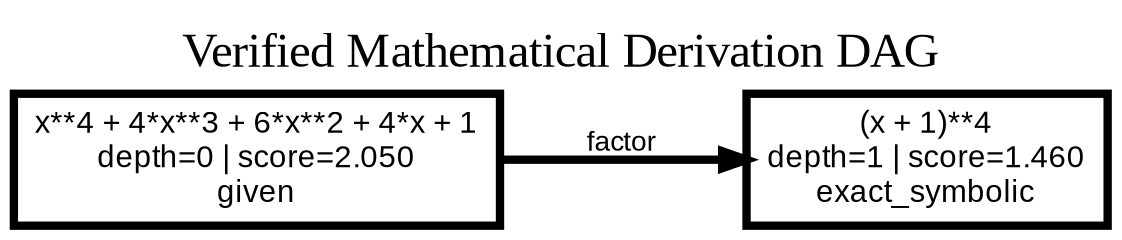

Saved 250 DPI PNG: /content/verified_mathematical_derivation_dag.png


In [17]:
"""Render the NetworkX derivation DAG as a downloadable 250 DPI PNG."""

from pathlib import Path

from google.colab import files
from IPython.display import Image, display

# ============================================================
# Control knobs
# ============================================================
DERIVATION_PNG_FILENAME = "verified_mathematical_derivation_dag.png"
GRAPHVIZ_DPI = 250


def render_derivation_graph(nx_graph, selected_path):
    """Convert a NetworkX derivation DAG into a Graphviz PNG.

    Args:
        nx_graph: Directed NetworkX graph containing derivation metadata.
        selected_path: Ordered selected-path dictionaries returned by the
            search engine.

    Returns:
        Graphviz Digraph containing the rendered derivation network.
    """
    selected_keys = [step["key"] for step in selected_path]
    selected_nodes = set(selected_keys)
    selected_edges = set(zip(selected_keys[:-1], selected_keys[1:]))

    dot = graphviz.Digraph(
        name="derivation_dag",
        format="png",
        engine="dot",
    )
    dot.attr(
        rankdir=GRAPHVIZ_RANKDIR,
        dpi=str(GRAPHVIZ_DPI),
        splines="spline",
        overlap="false",
        concentrate="false",
        nodesep="0.35",
        ranksep="0.70",
        labelloc="t",
        label="Verified Mathematical Derivation DAG",
    )
    dot.attr(
        "node",
        fontname="Helvetica",
        fontsize="9",
        margin="0.08,0.05",
    )
    dot.attr(
        "edge",
        fontname="Helvetica",
        fontsize="8",
        arrowsize="0.7",
    )

    node_ids = {
        key: f"n{index}"
        for index, key in enumerate(nx_graph.nodes)
    }

    for key, data in nx_graph.nodes(data=True):
        expression_text = sp.sstr(data["expr"])
        if len(expression_text) > GRAPHVIZ_MAX_LABEL_CHARS:
            expression_text = (
                expression_text[: GRAPHVIZ_MAX_LABEL_CHARS - 1] + "…"
            )

        label = (
            f"{expression_text}\n"
            f"depth={data['depth']} | "
            f"score={data['score_total']:.3f}\n"
            f"{data['verification']}"
        )

        if key in selected_nodes:
            dot.node(
                node_ids[key],
                label=label,
                shape="box",
                penwidth="2.4",
            )
        else:
            dot.node(
                node_ids[key],
                label=label,
                shape="ellipse",
                penwidth="0.9",
            )

    for source, target, data in nx_graph.edges(data=True):
        edge_key = (source, target)

        if edge_key in selected_edges:
            dot.edge(
                node_ids[source],
                node_ids[target],
                label=data["rule"],
                penwidth="2.4",
            )
        else:
            dot.edge(
                node_ids[source],
                node_ids[target],
                label=data["rule"],
                style="dashed",
                penwidth="0.8",
            )

    return dot


graph = poly_result["graph"]

derivation_dot = render_derivation_graph(
    graph,
    poly_result["selected_path"],
)

# ============================================================
# Render and save the 250 DPI PNG
# ============================================================
derivation_png = derivation_dot.pipe(format="png")

output_path = Path(DERIVATION_PNG_FILENAME)
output_path.write_bytes(derivation_png)

# Display the exact saved PNG in the notebook.
display(Image(filename=str(output_path)))

# Keep the DOT representation available for reproducible rendering.
DERIVATION_DOT_SOURCE = derivation_dot.source

print(f"Saved 250 DPI PNG: {output_path.resolve()}")

## Demonstration 2: trigonometric identity derivation

The target is structurally different from the starting expression, so the search records a transformation path instead of stopping merely because the two expressions are mathematically equivalent.

In [7]:
"""Derive a standard trigonometric identity."""

TRIG_START = sp.sin(x) ** 2 + sp.cos(x) ** 2
TRIG_TARGET = sp.Integer(1)

trig_result = search_derivation(
    start_expr=TRIG_START,
    target=TRIG_TARGET,
    objective={"kind": "exact_target"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES + ("expand_trig",),
    search_mode="best_first",
    context={"collect_symbol": x},
)

assert sp.srepr(trig_result["selected_path"][-1]["expr"]) == sp.srepr(TRIG_TARGET)

for index, step in enumerate(trig_result["selected_path"]):
    label = "start" if index == 0 else step["rule"]
    print(f"{index:>2}: {label:<12} {sp.sstr(step['expr'])}")

 0: start        sin(x)**2 + cos(x)**2
 1: trigsimp     1


## Demonstration 3: objective-driven derivation without an exact target

Here the engine receives `{"kind": "factor"}` instead of a target. Completion means the current expression is already in the structural form returned by `SymPy.factor`.

In [8]:
"""Search for a factorized canonical form without specifying a target."""

OBJECTIVE_START = x**4 - 5 * x**2 + 4

objective_result = search_derivation(
    start_expr=OBJECTIVE_START,
    target=None,
    objective={"kind": "factor"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES,
    search_mode="astar",
    context={"collect_symbol": x},
)

objective_terminal = objective_result["selected_path"][-1]["expr"]
assert sp.srepr(objective_terminal) == sp.srepr(sp.factor(objective_terminal))

display(
    Math(
        rf"{sp.latex(OBJECTIVE_START)}"
        rf"\longrightarrow {sp.latex(objective_terminal)}"
    )
)

<IPython.core.display.Math object>

## Clifford algebra and graded algebra

For an orthogonal basis, the Clifford relations are

$$
e_i e_j + e_j e_i = 2g_{ij},
$$

and in the diagonal case

$$
e_i^2=Q(e_i).
$$

The canonical reducer below sorts basis indices, tracks the parity of transpositions, and collapses repeated basis elements into metric factors. A homogeneous Clifford word has $\mathbb Z/2\mathbb Z$ grade equal to its word length modulo two.

For homogeneous graded factors, the tensor-product multiplication uses the Koszul sign

$$
(x_1\otimes x_2)(y_1\otimes y_2)
=
(-1)^{|x_2||y_1|}(x_1y_1)\otimes(x_2y_2).
$$

In [9]:
"""Implement Clifford canonical reduction and the Koszul sign rule."""


def reduce_clifford_word(word, diagonal_metric):
    """Reduce an orthogonal Clifford word to canonical ordered form.

    Args:
        word: Iterable of integer basis indices.
        diagonal_metric: Mapping i -> Q(e_i) = g_ii.

    Returns:
        Dictionary with coefficient, canonical word, and Z/2Z grade.
    """
    word = tuple(word)
    inversions = sum(
        left > right
        for index, left in enumerate(word)
        for right in word[index + 1 :]
    )
    coefficient = sp.Integer(-1) ** inversions
    counts = Counter(word)
    canonical = []

    for basis_index in sorted(counts):
        if basis_index not in diagonal_metric:
            raise KeyError(f"Missing Q(e_{basis_index}) in the metric.")
        count = counts[basis_index]
        coefficient *= sp.sympify(diagonal_metric[basis_index]) ** (count // 2)
        if count % 2:
            canonical.append(basis_index)

    return {
        "coefficient": sp.simplify(coefficient),
        "word": tuple(canonical),
        "grade": len(canonical) % 2,
    }


def graded_tensor_product(left, right):
    """Multiply homogeneous tensor factors using the Koszul sign rule.

    Args:
        left: Tuple ((x1, grade_x1), (x2, grade_x2)).
        right: Tuple ((y1, grade_y1), (y2, grade_y2)).

    Returns:
        Dictionary containing the Koszul sign and resulting graded factors.
    """
    (x1, grade_x1), (x2, grade_x2) = left
    (y1, grade_y1), (y2, grade_y2) = right
    sign = (-1) ** (grade_x2 * grade_y1)
    return {
        "sign": sign,
        "left_factor": x1 * y1,
        "right_factor": x2 * y2,
        "grades": (
            (grade_x1 + grade_y1) % 2,
            (grade_x2 + grade_y2) % 2,
        ),
    }


NEGATIVE_METRIC = {1: -1, 2: -1, 3: -1, 4: -1}
CLIFFORD_WORD = (3, 1, 2, 1, 3)
clifford_result = reduce_clifford_word(CLIFFORD_WORD, NEGATIVE_METRIC)

print("Input word:", CLIFFORD_WORD)
print("Coefficient:", clifford_result["coefficient"])
print("Canonical word:", clifford_result["word"])
print("Z/2Z grade:", clifford_result["grade"])

# The objective "clifford_canonical" is fulfilled by this domain adapter.
CLIFFORD_OBJECTIVE = {"kind": "clifford_canonical"}
assert clifford_result["word"] == tuple(sorted(clifford_result["word"]))

# Compact Koszul-sign demonstration: |x2| = |y1| = 1 gives a minus sign.
a, b, c, d = sp.symbols("a b c d", commutative=False)
koszul_result = graded_tensor_product(
    ((a, 0), (b, 1)),
    ((c, 1), (d, 0)),
)
print("Koszul sign:", koszul_result["sign"])
assert koszul_result["sign"] == -1

Input word: (3, 1, 2, 1, 3)
Coefficient: 1
Canonical word: (2,)
Z/2Z grade: 1
Koszul sign: -1


## Reusable Poincaré and graded-series bookkeeping

For an exact decomposition

$$
H(q)=A(q)X(q)+B(q)Y(q)+Z(q),
$$

the unknown component $X(q)$ can be recovered by exact polynomial division whenever the problem is well posed. A zero remainder certifies exact reconstruction in the polynomial ring.

In [10]:
"""Recover an unknown exact graded component and verify reconstruction."""


def recover_graded_component(h_poly, a_poly, b_poly, y_poly, z_poly, variable):
    """Recover X from H = A*X + B*Y + Z by exact polynomial division.

    Args:
        h_poly: Known total graded polynomial H.
        a_poly: Known multiplier A.
        b_poly: Known multiplier B.
        y_poly: Known graded component Y.
        z_poly: Known residual component Z.
        variable: Polynomial grading variable.

    Returns:
        Dictionary with quotient, remainder, and reconstruction status.
    """
    numerator = sp.Poly(
        sp.expand(h_poly - b_poly * y_poly - z_poly),
        variable,
        domain=sp.QQ,
    )
    denominator = sp.Poly(a_poly, variable, domain=sp.QQ)
    quotient, remainder = sp.div(numerator, denominator)
    recovered = quotient.as_expr()
    reconstructed = sp.expand(
        a_poly * recovered + b_poly * y_poly + z_poly
    )
    exact = remainder.is_zero and sp.expand(reconstructed - h_poly) == 0
    return {
        "quotient": recovered,
        "remainder": remainder.as_expr(),
        "reconstructed": reconstructed,
        "exact": bool(exact),
    }


q = sp.symbols("q")
A_Q = 1 + q + q**2
B_Q = 1 + q**2
X_TRUE = 1 + q**3 + q**5
Y_Q = q + q**4
Z_Q = q**7
H_Q = sp.expand(A_Q * X_TRUE + B_Q * Y_Q + Z_Q)

series_result = recover_graded_component(H_Q, A_Q, B_Q, Y_Q, Z_Q, q)

display(Math(rf"H(q)={sp.latex(H_Q)}"))
display(Math(rf"X(q)={sp.latex(series_result['quotient'])}"))
display(Math(rf"R(q)={sp.latex(series_result['remainder'])}"))

assert series_result["exact"]
assert sp.expand(series_result["quotient"] - X_TRUE) == 0

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Independent Z3 counterexample rejection

For supported polynomial expressions, the verifier asks whether a real or integer assignment satisfying the assumptions can make the residual nonzero. `unsat` means Z3 has rejected all such counterexamples within the encoded theory.

In [11]:
"""Demonstrate SMT verification of a polynomial identity."""

Z3_LHS = (x + 1) ** 2
Z3_RHS = x**2 + 2 * x + 1
z3_check = verify_equivalence(Z3_LHS, Z3_RHS, (x,))

print(z3_check)
assert z3_check["proved"]
assert z3_check["status"] in ("exact_symbolic", "smt_verified")

# Force the explicit Z3 route with an independently constructed solver.
zx = z3.Real("zx")
solver = z3.Solver()
solver.add((zx + 1) * (zx + 1) != zx * zx + 2 * zx + 1)
assert solver.check() == z3.unsat
print("Explicit Z3 counterexample search: unsat")

{'status': 'exact_symbolic', 'proved': True, 'mpmath_ok': True, 'cupy_ok': True, 'max_error': 0.0}
Explicit Z3 counterexample search: unsat


## CuPy batched numerical consistency check

This section performs a large CUDA batch independently of SymPy's exact result. It is useful for stress testing transformations over many admissible points. It remains a numerical consistency test, regardless of sample count.

In [12]:
"""Run an explicit CuPy batched numerical identity check on the GPU."""

if GPU_AVAILABLE:
    rng = cp.random.RandomState(RANDOM_SEED)
    x_gpu = rng.uniform(0.125, 3.0, size=GPU_SAMPLES)
    lhs_gpu = (x_gpu + 1.0) ** 4
    rhs_gpu = (
        x_gpu**4
        + 4.0 * x_gpu**3
        + 6.0 * x_gpu**2
        + 4.0 * x_gpu
        + 1.0
    )
    gpu_max_error = float(cp.max(cp.abs(lhs_gpu - rhs_gpu)).get())
    print(f"CuPy samples: {GPU_SAMPLES:,}")
    print(f"Maximum absolute residual: {gpu_max_error:.3e}")
    assert gpu_max_error <= 1e-9
else:
    print(
        "No CUDA device is active. In Google Colab, select a GPU runtime "
        "to execute the CuPy verification section."
    )

CuPy samples: 32,768
Maximum absolute residual: 5.684e-14


## LaTeX export

The selected polynomial path is exported as an `align` environment suitable for Overleaf. Transformation labels remain attached to individual steps.

In [13]:
"""Export the selected derivation as an Overleaf-ready LaTeX align block."""

latex_lines = [r"\begin{align}"]
for index, step in enumerate(poly_result["selected_path"]):
    expression_latex = sp.latex(step["expr"])
    if index == 0:
        latex_lines.append(rf"E_0 &= {expression_latex} \\")
    else:
        latex_lines.append(
            rf"E_{index} &= {expression_latex} "
            rf"\qquad \text{{[{step['rule']}]}} \\"
        )
latex_lines.append(r"\end{align}")

latex_derivation = "\n".join(latex_lines)
print(latex_derivation)

\begin{align}
E_0 &= x^{4} + 4 x^{3} + 6 x^{2} + 4 x + 1 \\
E_1 &= \left(x + 1\right)^{4} \qquad \text{[factor]} \\
\end{align}


## Extension data model

The current implementation keeps topology-specific components outside the core search so they can later use a SageMath backend without changing the symbolic search API.

```text
Automated Mathematical Derivation Engine
│
├── Symbolic algebra
│   ├── exact rewrites
│   ├── objective-driven search
│   └── assumptions
│
├── Verification
│   ├── SymPy exact checks
│   ├── Z3 SMT checks
│   ├── mpmath high-precision checks
│   └── CuPy batched GPU checks
│
├── Derivation graph
│   ├── competing branches
│   ├── transparent scoring
│   ├── pruning
│   └── ranked paths
│
├── Clifford algebra
│   ├── canonical words
│   ├── metric factors
│   ├── Z/2Z grading
│   └── Koszul signs
│
├── Graded algebra
│   ├── graded tensor products
│   ├── modules
│   └── chain complexes
│
├── Exact sequences
│   ├── kernels
│   ├── images
│   ├── quotient objects
│   └── exactness checks
│
└── Optional SageMath backend
    ├── groups
    ├── rings and modules
    ├── Clifford algebras
    ├── Steenrod algebra
    ├── chain complexes
    ├── homology and cohomology
    └── selected bordism computations
```

The schema below records these future interfaces without importing SageMath in the Colab runtime.

In [14]:
"""Declare extension interfaces for later algebraic-topology backends."""

EXTENSION_SCHEMA = {
    "graded_module": {
        "ring": None,
        "generators": [],
        "degrees": {},
        "relations": [],
    },
    "chain_complex": {
        "chain_groups": {},
        "boundary_maps": {},
        "coefficient_ring": None,
    },
    "exact_sequence": {
        "objects": [],
        "maps": [],
        "kernels": {},
        "images": {},
        "exactness": {},
    },
    "sage_backend": {
        "enabled": False,
        "capabilities": (
            "groups",
            "rings",
            "modules",
            "steenrod_algebra",
            "homology",
            "cohomology",
            "bordism_bookkeeping",
        ),
    },
}

print(EXTENSION_SCHEMA["sage_backend"])

{'enabled': False, 'capabilities': ('groups', 'rings', 'modules', 'steenrod_algebra', 'homology', 'cohomology', 'bordism_bookkeeping')}


## Lightweight integrity checks

The notebook already asserts the principal demonstrations. The checks below confirm graph acyclicity, path verification metadata, exact polynomial reconstruction, and Clifford canonical ordering.

In [15]:
"""Run compact integrity checks across the notebook."""

assert nx.is_directed_acyclic_graph(poly_result["graph"])
assert all(
    poly_result["graph"].edges[source, target]["verification"]
    in ("exact_symbolic", "smt_verified", "numerically_consistent")
    for source, target in poly_result["graph"].edges
)
assert series_result["exact"]
assert clifford_result["word"] == tuple(sorted(clifford_result["word"]))
assert koszul_result["sign"] == -1
assert candidate_table.shape[0] >= 1
assert "digraph" in DERIVATION_DOT_SOURCE
assert len(derivation_svg) > 0

print("All integrity checks passed.")

All integrity checks passed.
